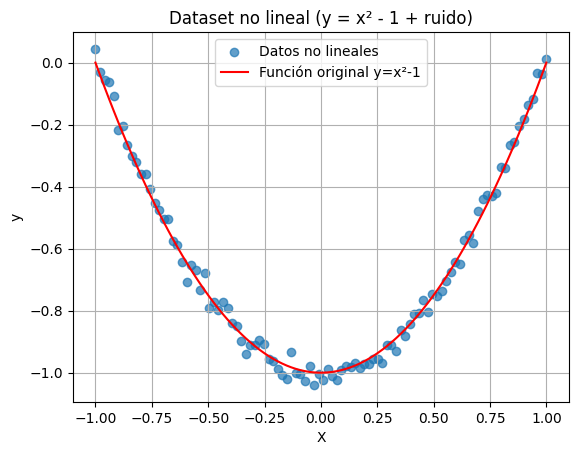

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset no lineal: y = x² - 1 + ruido
np.random.seed(0)
X = np.linspace(-1, 1, 100)
y = X**2 - 1 + np.random.normal(0, .025, size=X.shape)

# Visualización
plt.scatter(X, y, label='Datos no lineales', alpha=0.7)
plt.plot(X, X**2 - 1, color='red', label='Función original y=x²-1')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset no lineal (y = x² - 1 + ruido)")
plt.legend()
plt.grid()
plt.show()

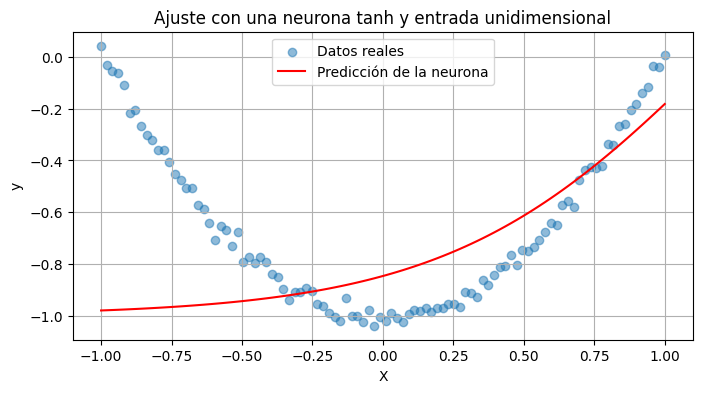

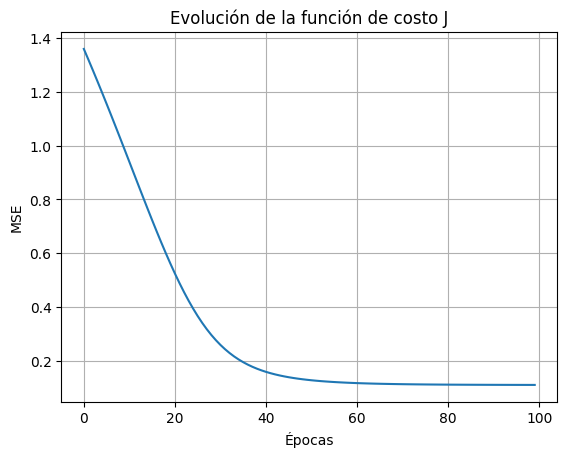

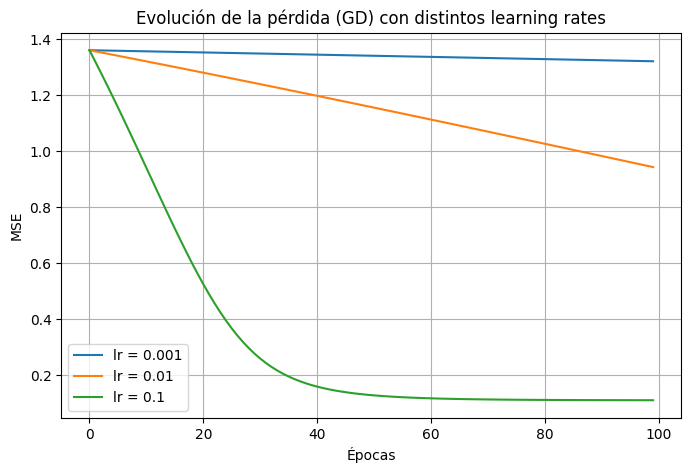

In [63]:
# Activación tanh y su derivada
def tanh(x):
    return np.tanh(x)


def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

# Neurona con tanh


def single_neuron_tanh(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    epochs: int = 100
) -> tuple[float, float, list[float], list[tuple[float, float, float]]]:
    """
    Trains a single neuron model using the hyperbolic tangent (tanh) activation function.
    Parameters:
    -----------
    X : numpy.ndarray
        Input feature(s), expected to be a 1D array. It will be reshaped into a column vector.
    y : numpy.ndarray
        Target values, expected to be a 1D array. It will be reshaped into a column vector.
    lr : float, optional
        Learning rate for gradient descent. Default is 0.1.
    epochs : int, optional
        Number of iterations for training. Default is 100.
    Returns:
    --------
    w : float
        Trained weight for the input feature.
    b : float
        Trained bias term.
    loss_history : list
        List of loss values (mean squared error) for each epoch during training.
    trace : list
        List of tuples containing (weight, bias, loss) at each epoch for tracing the model's evolution.
    Notes:
    ------
    - The function uses the tanh activation function and its derivative for backpropagation.
    - The weight and bias are initialized randomly using a fixed seed for reproducibility.
    - The loss is calculated as the mean squared error between the predicted and actual values.
    """
    X = X.reshape(-1, 1)  # aseguramos forma columna
    y = y.reshape(-1, 1)  # aseguramos columna

    # Inicialización
    np.random.seed(0)
    w = np.random.randn()  # peso para x
    b = np.random.randn()
    loss_history = []
    trace = []  # para almacenar la evolución del modelo

    for i in range(epochs):
        z = X * w + b
        y_hat = tanh(z)
        error = y_hat - y
        dz = error * tanh_deriv(z)

        dw = np.mean(dz * X)
        db = np.mean(dz)

        w -= lr * dw
        b -= lr * db

        J = np.mean((y_hat - y)**2)
        loss_history.append(J)
        trace.append((w, b, J))

    return w, b, loss_history, trace


# Entrenamos
w, b, losses, trace_gd = single_neuron_tanh(X, y)

# Predicción
y_pred = tanh(X * w + b)

# Gráfico de datos y predicción
plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.5, label="Datos reales")
plt.plot(X, y_pred, color='red', label="Predicción de la neurona")
plt.title("Ajuste con una neurona tanh y entrada unidimensional")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Curva de pérdida
plt.plot(losses)
plt.title("Evolución de la función de costo J")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Probar con diferentes learning rates
lrs = [0.001, 0.01, 0.1]
losses_dict = {}

for lr in lrs:
    _, _, losses, _ = single_neuron_tanh(X, y, lr=lr)
    losses_dict[lr] = losses

plt.figure(figsize=(8, 5))

for lr, losses in losses_dict.items():
    plt.plot(losses, label=f"lr = {lr}")

plt.title("Evolución de la pérdida (GD) con distintos learning rates")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

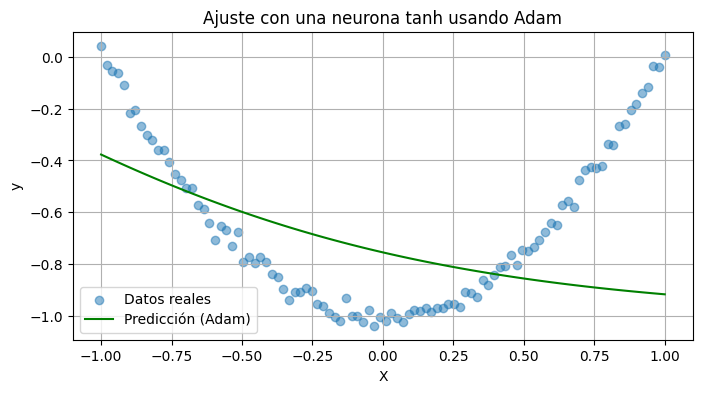

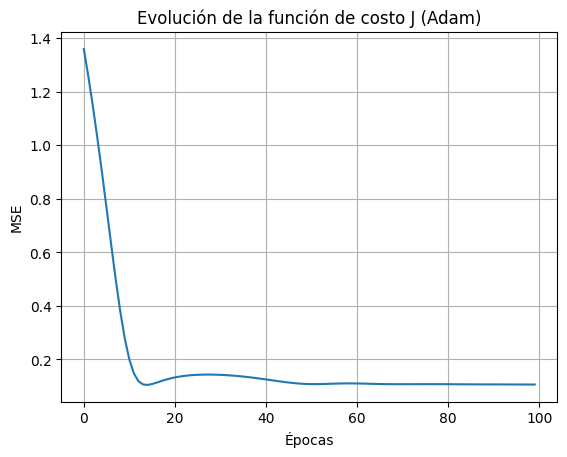

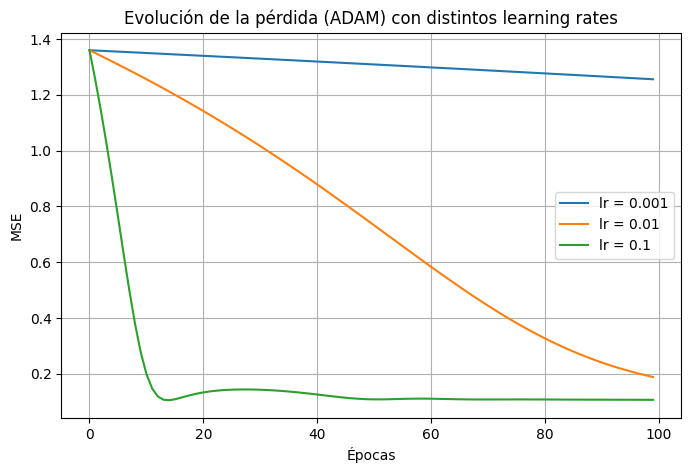

In [64]:
# Neurona con tanh usando Adam
def single_neuron_tanh_adam(X, y, lr=0.1, epochs=100, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Entrena una única neurona usando activación tanh y el optimizador Adam.

    Parámetros:
    -----------
    X : numpy.ndarray
        Vector de entrada (1D), se convertirá a columna.
    y : numpy.ndarray
        Vector objetivo (1D), se convertirá a columna.
    lr : float
        Tasa de aprendizaje.
    epochs : int
        Número de épocas de entrenamiento.
    beta1, beta2 : float
        Coeficientes de decaimiento para los momentos.
    eps : float
        Término de estabilización numérica.

    Retorna:
    --------
    w : float
        Peso entrenado.
    b : float
        Sesgo entrenado.
    loss_history : list
        Historial de la función de pérdida.
    """
    X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)

    # Inicialización
    np.random.seed(0)
    w = np.random.randn()
    b = np.random.randn()
    loss_history = []

    # Inicializar momentos para w y b
    mw, vw = 0.0, 0.0
    mb, vb = 0.0, 0.0
    trace = []  # Para guardar el rastro de los parámetros

    for t in range(1, epochs + 1):
        z = X * w + b
        y_hat = tanh(z)
        error = y_hat - y
        dz = error * tanh_deriv(z)

        dw = np.mean(dz * X)
        db = np.mean(dz)

        # Actualización de momentos (Adam)
        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)
        mw_corr = mw / (1 - beta1 ** t)
        vw_corr = vw / (1 - beta2 ** t)

        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * (db ** 2)
        mb_corr = mb / (1 - beta1 ** t)
        vb_corr = vb / (1 - beta2 ** t)

        # Actualización de parámetros
        w -= lr * mw_corr / (np.sqrt(vw_corr) + eps)
        b -= lr * mb_corr / (np.sqrt(vb_corr) + eps)

        # Calcular pérdida y guardar
        J = np.mean((y_hat - y) ** 2)
        loss_history.append(J)
        trace.append((w, b, J))

    return w, b, loss_history, trace


# Entrenar usando Adam
w_adam, b_adam, losses_adam, trace_adam = single_neuron_tanh_adam(X, y)

# Predicción
y_pred_adam = tanh(X * w_adam + b_adam)

# Gráfico de ajuste
plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.5, label="Datos reales")
plt.plot(X, y_pred_adam, color='green', label="Predicción (Adam)")
plt.title("Ajuste con una neurona tanh usando Adam")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de pérdida
plt.plot(losses_adam)
plt.title("Evolución de la función de costo J (Adam)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Probar con diferentes learning rates
lrs = [0.001, 0.01, 0.1]
losses_dict = {}

for lr in lrs:
    _, _, losses, _ = single_neuron_tanh_adam(X, y, lr=lr)
    losses_dict[lr] = losses
    
plt.figure(figsize=(8, 5))

for lr, losses in losses_dict.items():
    plt.plot(losses, label=f"lr = {lr}")

plt.title("Evolución de la pérdida (ADAM) con distintos learning rates")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

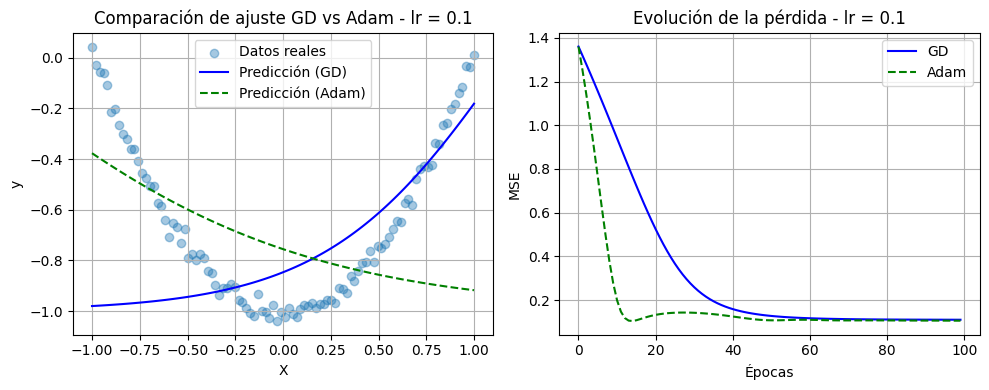

In [65]:
# Entrenar con ambos métodos
w_gd, b_gd, losses_gd, _ = single_neuron_tanh(X, y)
w_adam, b_adam, losses_adam, _ = single_neuron_tanh_adam(X, y)

# Predicciones
y_pred_gd = tanh(X * w_gd + b_gd)
y_pred_adam = tanh(X * w_adam + b_adam)

# Comparación de ajustes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.4, label="Datos reales")
plt.plot(X, y_pred_gd, color='blue', label="Predicción (GD)")
plt.plot(X, y_pred_adam, color='green', linestyle='--', label="Predicción (Adam)")
plt.title("Comparación de ajuste GD vs Adam - lr = 0.1")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Comparación de evolución de la pérdida
plt.subplot(1, 2, 2)
plt.plot(losses_gd, label="GD", color='blue')
plt.plot(losses_adam, label="Adam", color='green', linestyle='--')
plt.title("Evolución de la pérdida - lr = 0.1")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


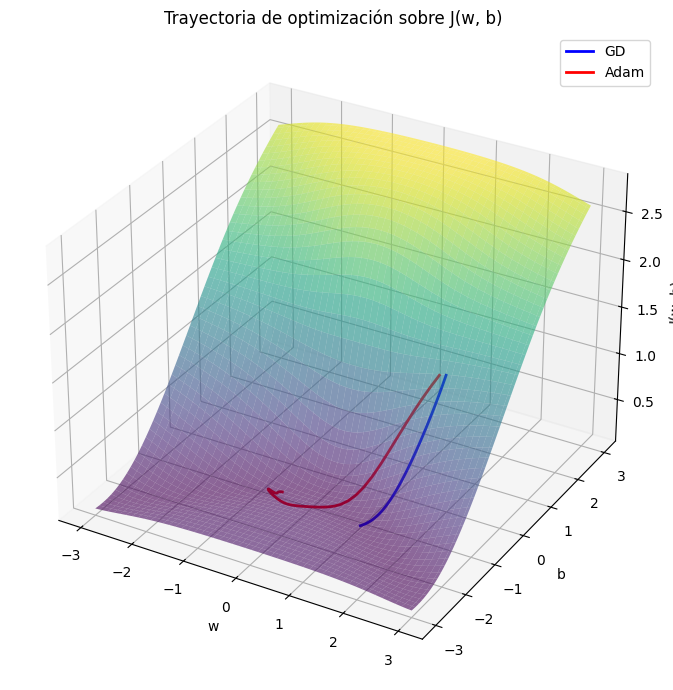

In [66]:
# Función de costo J(w, b)
def compute_loss(X, y, w, b):
    y_hat = tanh(X * w + b)
    return np.mean((y - y_hat)**2)

# Construimos la malla para la superficie
w_vals = np.linspace(-3, 3, 100)
b_vals = np.linspace(-3, 3, 100)
W, B = np.meshgrid(w_vals, b_vals)

# Evaluamos J(w, b) para cada punto
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_loss(X, y, W[i, j], B[i, j])


# Extraer coordenadas
w_gd, b_gd, j_gd = zip(*trace_gd)
w_adam, b_adam, j_adam = zip(*trace_adam)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Superficie de pérdida
ax.plot_surface(W, B, J_vals, cmap='viridis', alpha=0.6, edgecolor='none')

# Trayectorias
ax.plot(w_gd, b_gd, j_gd, color='blue', label='GD', linewidth=2)
ax.plot(w_adam, b_adam, j_adam, color='red', label='Adam', linewidth=2)

# Etiquetas
ax.set_title("Trayectoria de optimización sobre J(w, b)")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.legend()

plt.tight_layout()
plt.show()


En la figura se observa la superficie de la función de costo $𝐽(𝑤,𝑏)$ junto con las trayectorias de los optimizadores GD (azul) y Adam (rojo).

Ambos optimizadores parten del mismo punto inicial. Sin embargo, Adam presenta una convergencia más rápida y directa hacia la zona de mínimo, debido a sus mecanismos adaptativos de momento y escalado de gradientes.

En contraste, GD avanza con pasos más pequeños y requiere más iteraciones para alcanzar una región cercana al mínimo.

Esta visualización permite apreciar claramente cómo las decisiones de actualización de parámetros influyen en la velocidad y eficiencia de la optimización.

---



# pregunta 2

Primeras filas del dataset:
   User_ID Product_ID    Age Gender  Marital_Status City_Category  \
0  1044096  P00017122  46-50      F               1             B   
1  1071818  P00074517  36-45      M               0             A   
2  1022986  P00013694  36-45      M               1             A   
3  1094684  P00049122  36-45      M               1             A   
4  1004157  P00006469  46-50      M               1             A   

  Stay_In_Current_City_Years  Product_Category  Product_Subcategory_1  \
0                          1                10                   45.0   
1                          3                11                   27.0   
2                         5+                 4                   28.0   
3                          1                16                    9.0   
4                         5+                 3                    NaN   

   Product_Subcategory_2  Purchase  
0                    NaN      1810  
1                    NaN     12351  
2      

<Axes: >

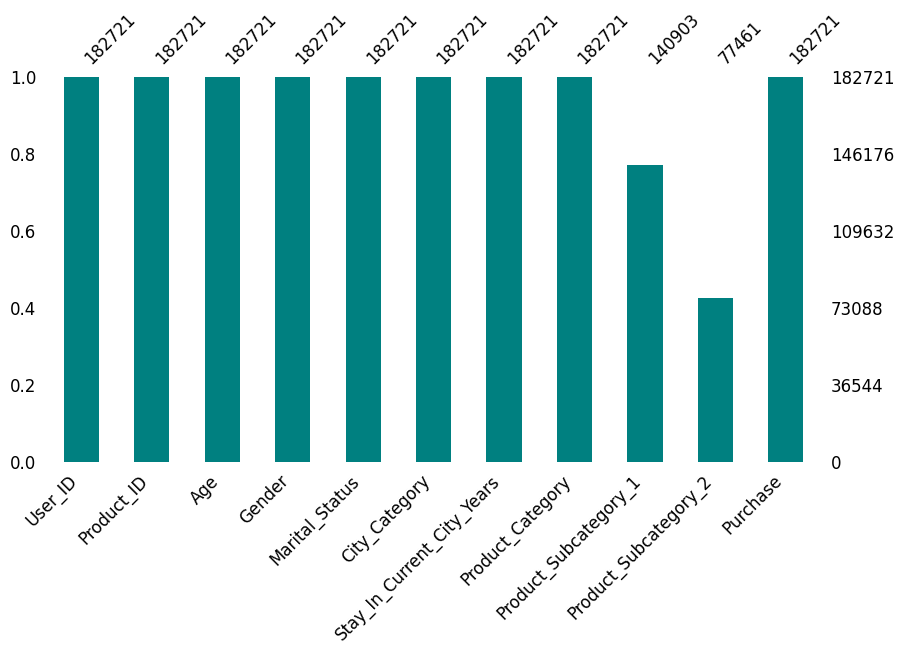

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 1. Cargar el dataset
df = pd.read_csv("dataset_compras.csv")

# 2. Vista preliminar de los datos
print("Primeras filas del dataset:")
print(df.head())

# 3. Porcentaje de valores nulos por columna
missing_percentage = df.isnull().mean() * 100
missing_df = missing_percentage.sort_values(ascending=False).reset_index()
missing_df.columns = ['Columna', 'Porcentaje de Nulos']

print("\nPorcentaje de nulos por columna:")
print(missing_df)

# 4. Informacion estadística del dataset
print("\nInformación estadística del dataset:")
print(df.describe())

# 5. Infomacion general del dataset
print("\nInformación general del dataset:")
print(df.info())

# 6. Visualización de los nulos
msno.bar(df, figsize=(10, 5), color='teal', fontsize=12)



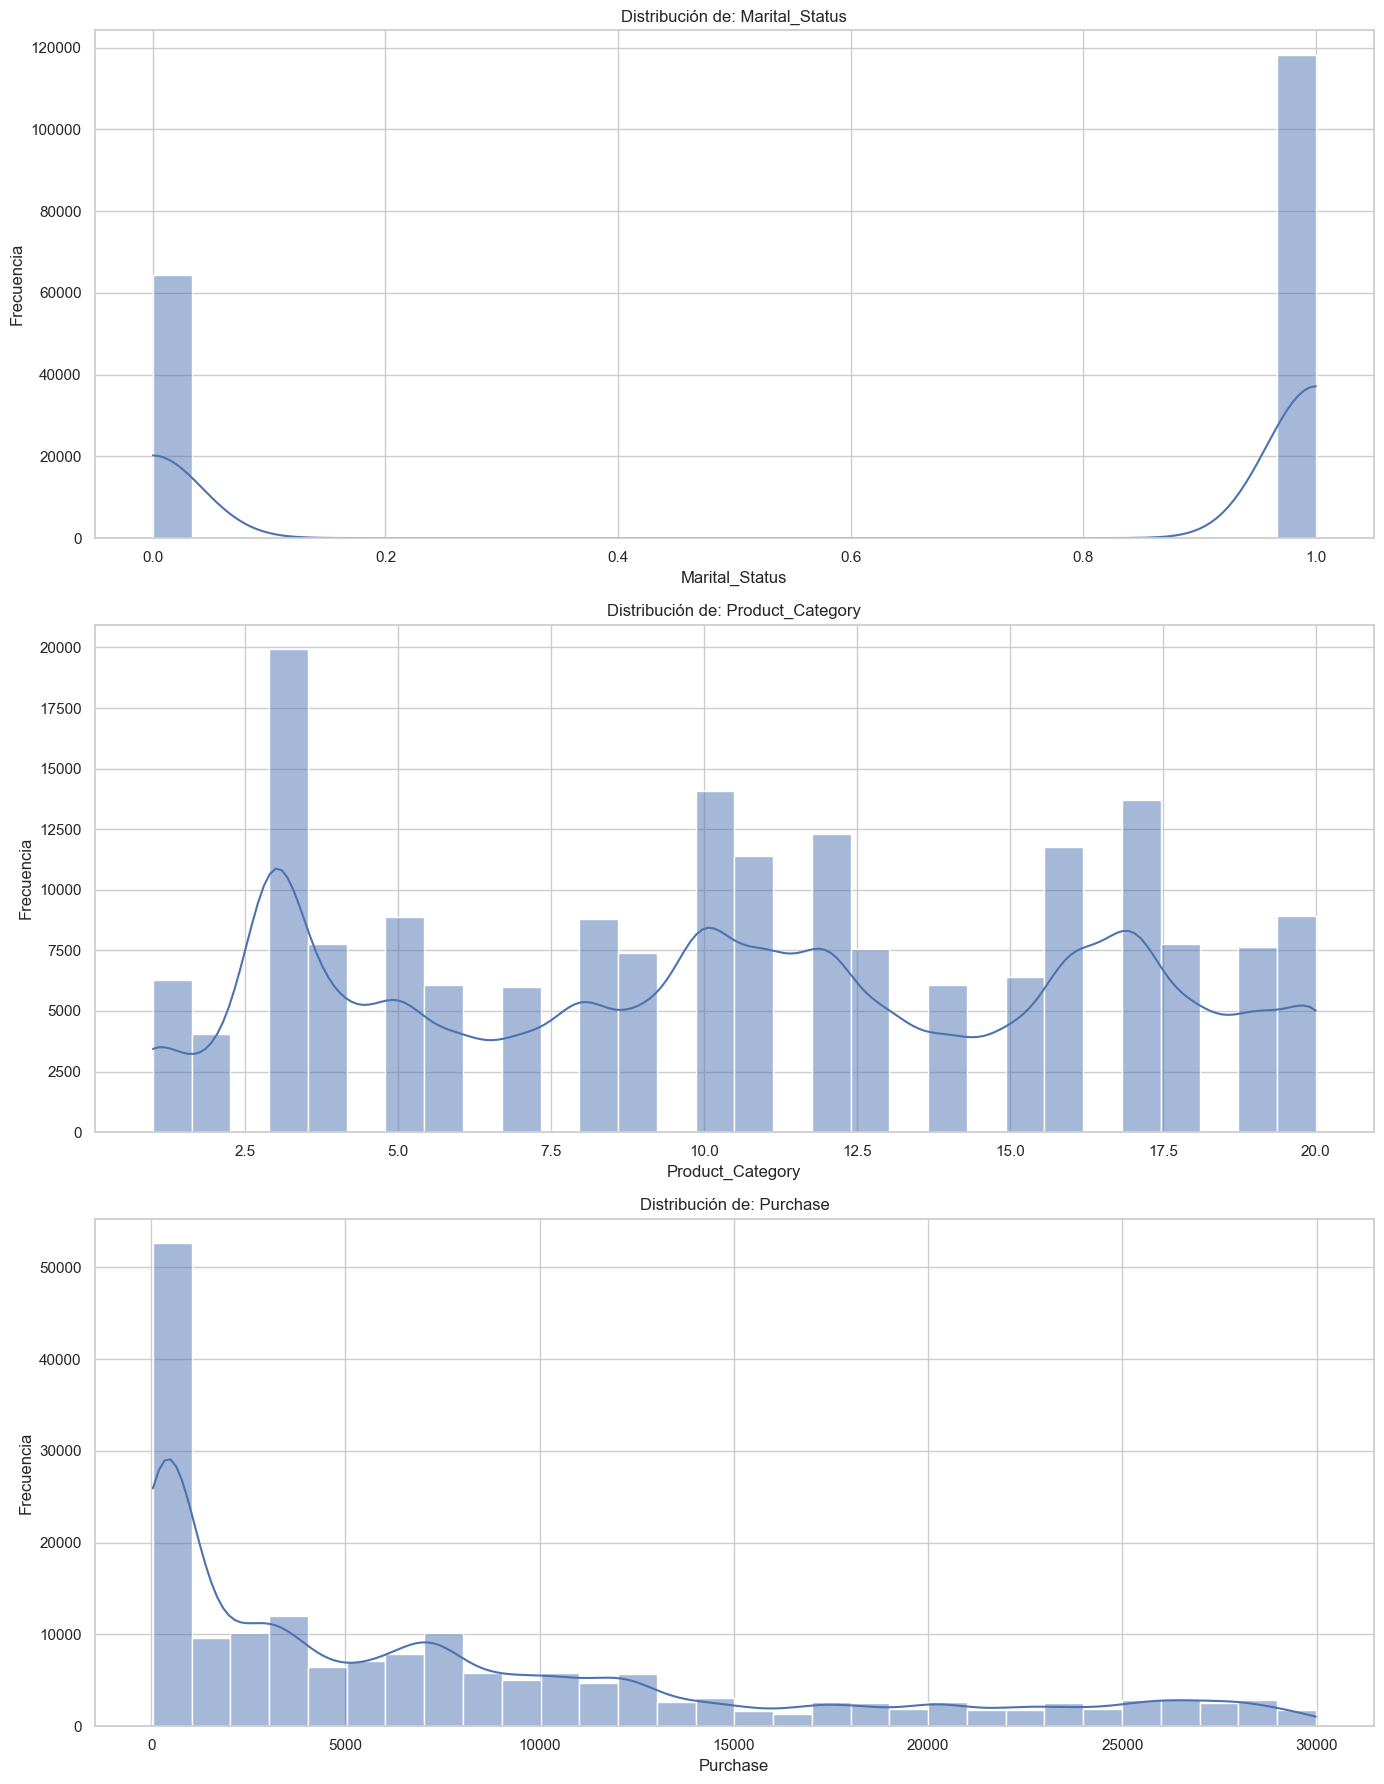

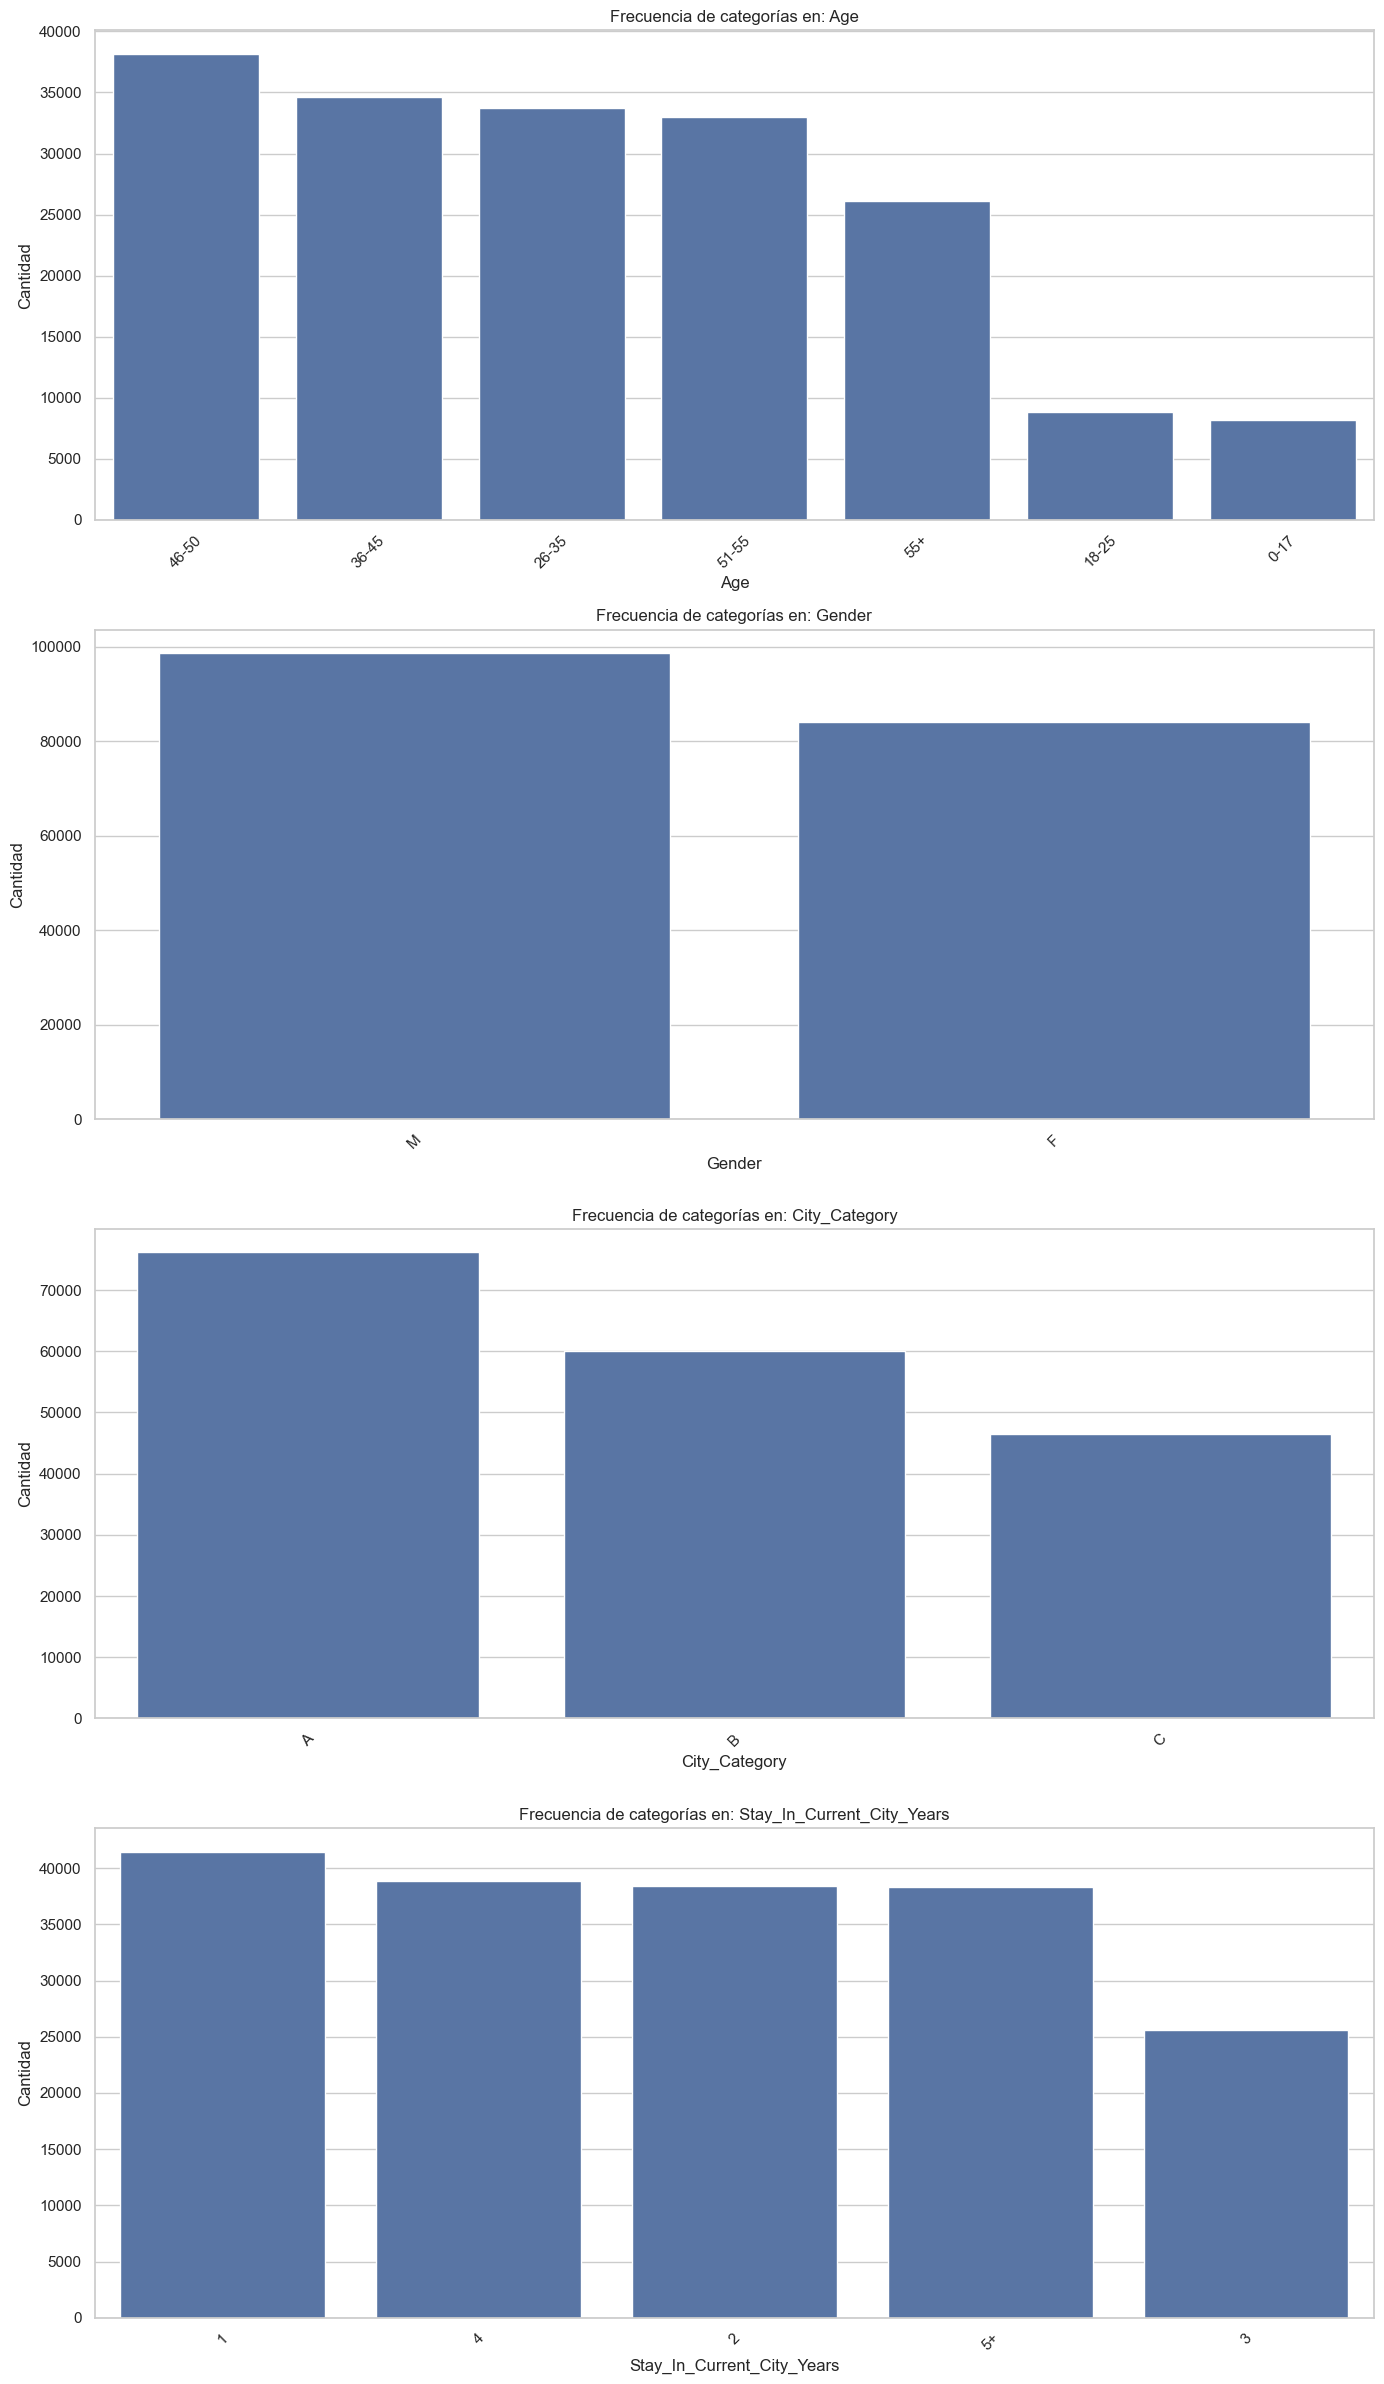

In [2]:
# Excepciones a excluir en ambos gráficos
columnas_excluir = [
    "User_ID", "Product_ID", "Product_Subcategory_1", "Product_Subcategory_2"
]

# Actualizar listas excluyendo esas columnas
columnas_numericas = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in columnas_excluir
]
columnas_categoricas = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if col not in columnas_excluir
]

# Graficar histogramas solo para columnas numéricas filtradas
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6 * len(columnas_numericas)))

for i, col in enumerate(columnas_numericas):
    plt.subplot(len(columnas_numericas), 1, i + 1)
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribución de: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# Volvemos a generar los countplots excluyendo columnas irrelevantes
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6 * len(columnas_categoricas)))

for i, col in enumerate(columnas_categoricas):
    plt.subplot(len(columnas_categoricas), 1, i + 1)
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=orden)
    plt.title(f"Frecuencia de categorías en: {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



## 🧭 Análisis Exploratorio de Datos (EDA) – Parte 2a

### 🔍 Diagnóstico inicial del dataset

- Tamaño: 182.721 registros y 11 columnas.
- Columnas como `User_ID` y `Product_ID` se consideran identificadores y no aportan información directamente útil para modelos tradicionales.
- Existen variables mixtas:
  - `Age`, `Stay_In_Current_City_Years`: son categóricas aunque aparenten ser numéricas.
  - `Gender`, `Marital_Status`, `City_Category`: categóricas con pocas clases.
  - `Product_Subcategory_1` y `2` presentan una gran cantidad de valores nulos (hasta 57%).

### 🛠️ Decisiones tomadas

- Se eliminarán las columnas `Product_Subcategory_1` y `Product_Subcategory_2`.
- Se transformará la variable objetivo `Purchase` en una categoría (`Segmento`) con 4 clases:
  - **Casual**: < 3000
  - **Gama media**: 3000–7999
  - **Gama alta**: 8000–17999
  - **Premium**: ≥ 18000
- Se codificarán las variables categóricas con **One Hot Encoding**, **sin `drop_first`**, ya que se utilizarán modelos basados en árboles.

### 📊 Análisis exploratorio de variables

A continuación se detallan los principales hallazgos obtenidos a partir de los histogramas y countplots:

- **Marital_Status**: Aunque representada numéricamente (0 y 1), se trata de una variable binaria. Se observa que la mayoría de los usuarios están casados.
- **Product_Category**: Presenta una distribución relativamente amplia y dispersa, sin una única categoría dominante, lo que sugiere variedad en los tipos de productos adquiridos.
- **Purchase**: Tiene una distribución asimétrica positiva, con alta concentración de valores bajos y una cola larga hacia la derecha. Esta forma es típica de una distribución de tipo *Tweedie* (Gamma-Poisson), pero en este análisis no se aplicará transformación logarítmica ya que se trabajará con una variable categórica (`Segmento`) derivada de ella.
- **Age**: Las categorías correspondientes a edades más jóvenes (`0-17`, `18-25`) son las menos representadas. La mayor concentración de compradores se encuentra entre los 26 y 45 años.
- **Gender**: La distribución está razonablemente balanceada, con una leve mayoría de hombres.
- **City_Category**: La ciudad de tipo "A" es la más representada entre los registros.
- **Stay_In_Current_City_Years**: La categoría "3 años" es la menos frecuente. El resto de los grupos está bastante equilibrado.

En base a estos patrones, se tomarán decisiones para el preprocesamiento y la selección de variables en el modelado.


---

## ⏭️ Siguientes pasos:

1. Crear la columna `Segmento`.
2. Limpiar columnas innecesarias.
3. Estandarizar formato (`Stay_In_Current_City_Years`).
4. Separar features y target para modelado.


In [2]:
def crear_segmento(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea la columna 'Segmento' basada en los valores de 'Purchase'.

    :param df: DataFrame original.
    :return: DataFrame con la nueva columna 'Segmento'.
    """
    bins = [0, 3000, 8000, 18000, float("inf")]
    labels = ["Casual", "Gama media", "Gama alta", "Premium"]
    df["Segmento"] = pd.cut(df["Purchase"], bins=bins, labels=labels, right=False)
    return df


def limpiar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Elimina columnas innecesarias del DataFrame.

    :param df: DataFrame original.
    :return: DataFrame sin columnas ID y subcategorías.
    """
    columnas_a_eliminar = [
        "User_ID",
        "Product_ID",
        "Product_Subcategory_1",
        "Product_Subcategory_2"
    ]
    df = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])
    return df


def estandarizar_formatos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estandariza el formato de columna 'Stay_In_Current_City_Years' 
    y mapea 'Marital_Status' de binaria numérica a categórica con etiquetas.

    :param df: DataFrame original.
    :return: DataFrame estandarizado.
    """
    df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace("5+", 5).astype(int)
    df["Marital_Status"] = df["Marital_Status"].map({1: "Casado", 0: "Soltero"}).astype("category")

    return df


def preparar_datos_para_modelado(df: pd.DataFrame, target_col: str) -> tuple:
    """
    Separa las variables predictoras (X) y la variable objetivo (y).

    :param df: DataFrame procesado.
    :param target_col: Nombre de la columna objetivo.
    :return: Tupla con X e y.
    """
    df = df.drop(columns=["Purchase"])  # eliminar la variable de fuga
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


# Ejecución del pipeline de preprocesamiento
df = crear_segmento(df)
df = limpiar_columnas(df)
df = estandarizar_formatos(df)

X, y = preparar_datos_para_modelado(df, target_col="Segmento")

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Detectar columnas por tipo
cat_cols = X_train.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Definir columna ordinal y su orden
col_ordinal = ["Age"]
orden_edad = [["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]]

# Separar categóricas ordinales de nominales
cat_nominal = [col for col in cat_cols if col not in col_ordinal]

# Preprocesador para modelos que requieren drop_first=True
preprocessor_with_drop = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("nom", OneHotEncoder(drop="first"), cat_nominal),
    ("ord", OrdinalEncoder(categories=orden_edad), col_ordinal)
])

# Preprocesador para modelos que NO requieren drop
preprocessor_without_drop = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("nom", OneHotEncoder(), cat_nominal),
    ("ord", OrdinalEncoder(categories=orden_edad), col_ordinal)
])

# Modelos que requieren drop_first=True (modelos lineales)
modelos_con_drop = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    #"SVM": SVC(probability=True, random_state=42)
}

# Modelos que NO requieren drop (árboles, KNN, XGBoost)
modelos_sin_drop = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(tree_method = "hist", device = "cuda", eval_metric="mlogloss", random_state=42)
}

# Crear diccionario de pipelines
pipelines = {}

# Asociar modelos con el preprocesador correspondiente
for nombre, modelo in modelos_con_drop.items():
    pipelines[nombre] = Pipeline([
        ("preprocesamiento", preprocessor_with_drop),
        ("clasificador", modelo)
    ])

for nombre, modelo in modelos_sin_drop.items():
    pipelines[nombre] = Pipeline([
        ("preprocesamiento", preprocessor_without_drop),
        ("clasificador", modelo)
    ])


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

resultados = {}

for nombre, pipeline in pipelines.items():
    print(f"\n📌 Modelo: {nombre}")
    
    if nombre == "XGBoost":
        pipeline.fit(X_train, y_train_enc)
        y_pred = pipeline.predict(X_test)
        y_true = y_test_enc
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_true = y_test

    # Reporte clasico
    print(classification_report(y_true, y_pred, zero_division=0))

    # 🔲 Matriz de confusión absoluta
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"Matriz de Confusión (absoluta): {nombre}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    
    # 🔳 Matriz de confusión normalizada (por fila)
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=pipeline.classes_).plot()
    plt.title(f"Matriz de Confusión (normalizada): {nombre}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    resultados[nombre] = {
        "y_pred": y_pred,
        "y_test": y_true
    }

##  Punto 2b — Comparación de modelos

Se evaluaron distintos algoritmos de clasificación sobre el dataset completo, utilizando como variable objetivo la clase `Segmento` derivada del monto de compra (`Purchase`). A continuación se resumen los principales resultados de accuracy y F1-score por modelo:

- **XGBoost** fue el modelo con mejor desempeño general, con un `accuracy` del 76% y un F1-score ponderado de 0.76. Aprovecha eficientemente la GPU y maneja muy bien relaciones no lineales y categóricas.
- **Random Forest** y **Árbol de Decisión** obtuvieron resultados prácticamente equivalentes a XGBoost, lo que sugiere que la estructura del problema es fuertemente dominada por patrones que los árboles captan muy bien.
- **K-Nearest Neighbors (KNN)** mostró un rendimiento ligeramente inferior (accuracy de 73%), pero mantuvo métricas aceptables.
- **Regresión Logística** presentó resultados significativamente más bajos (accuracy de 43% y F1-score de 0.37), lo que confirma que la relación entre las variables predictoras y la clase objetivo no es lineal.

###  Consideración sobre el modelo SVM

Inicialmente se incluyó también el modelo **SVM** (Support Vector Machine). Sin embargo, su rendimiento fue deficiente incluso usando solo el 10% del dataset (accuracy ≈ 50%, F1-score < 0.45), y el tiempo de entrenamiento fue excesivo: con el dataset completo, luego de 40 minutos seguía sin finalizar. Por estas razones, se decidió **excluirlo de la comparación final**, aunque sigue disponible en el pipeline por si se desea utilizar en futuras pruebas o en un entorno optimizado.

---


## Punto 2c — Modelo de Deep Learning sin embeddings

Se implementó un modelo de deep learning utilizando PyTorch, respetando las restricciones del enunciado: no se utilizaron embeddings y se descartaron las columnas `product_id` y `user_id`.

La arquitectura del modelo consistió en una red densa multicapa con activación `GELU`, regularización con `Dropout`, y scheduler `StepLR` para ajustar dinámicamente la tasa de aprendizaje. Se entrenó durante 15 épocas utilizando `AdamW` como optimizador y una tasa de aprendizaje inicial de `1e-3`.

---

### **Justificación del proceso y resultados**

Durante el entrenamiento se aplicaron múltiples iteraciones explorando variantes arquitectónicas y de entrenamiento: número de capas ocultas, tamaño de batch, dropout, tipo de activación (`GELU`, `ReLU`, `LeakyReLU`), y técnicas de regularización. También se implementaron métricas macro (`f1-score`) y análisis visual para validar el comportamiento del modelo.

El modelo mostró un buen comportamiento de generalización sin señales de overfitting, con curvas suaves y estables. A pesar de no alcanzar el umbral propuesto del 78%, se logró un techo de rendimiento cercano al 76%.

---

### **Resultados Finales (época 15)**

- **Train Accuracy:** 75.78%  
- **Test Accuracy:** 76.30%  
- **Train F1 Score:** 71.52%  
- **Test F1 Score:** 72.20%


Epoch 01: Train Acc: 62.42% | Test Acc: 69.62% | Train F1: 58.20% | Test F1: 66.07%
Epoch 02: Train Acc: 72.40% | Test Acc: 75.48% | Train F1: 68.00% | Test F1: 71.48%
Epoch 03: Train Acc: 74.64% | Test Acc: 75.13% | Train F1: 70.32% | Test F1: 70.25%
Epoch 04: Train Acc: 75.11% | Test Acc: 76.38% | Train F1: 70.77% | Test F1: 72.30%
Epoch 05: Train Acc: 75.34% | Test Acc: 75.91% | Train F1: 71.03% | Test F1: 71.51%
Epoch 06: Train Acc: 75.65% | Test Acc: 76.42% | Train F1: 71.32% | Test F1: 72.39%
Epoch 07: Train Acc: 75.67% | Test Acc: 76.19% | Train F1: 71.39% | Test F1: 72.04%
Epoch 08: Train Acc: 75.69% | Test Acc: 75.73% | Train F1: 71.45% | Test F1: 71.31%
Epoch 09: Train Acc: 75.78% | Test Acc: 76.42% | Train F1: 71.54% | Test F1: 72.39%
Epoch 10: Train Acc: 75.84% | Test Acc: 76.49% | Train F1: 71.66% | Test F1: 72.49%


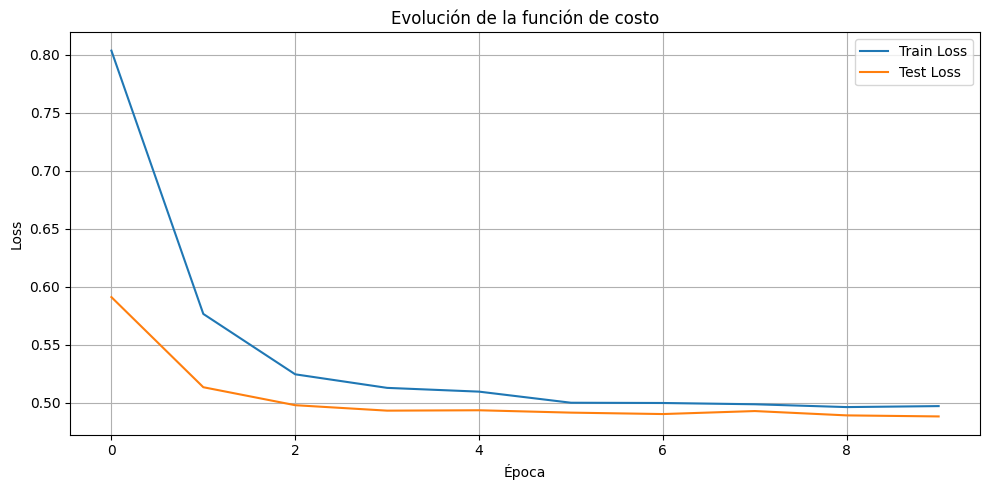

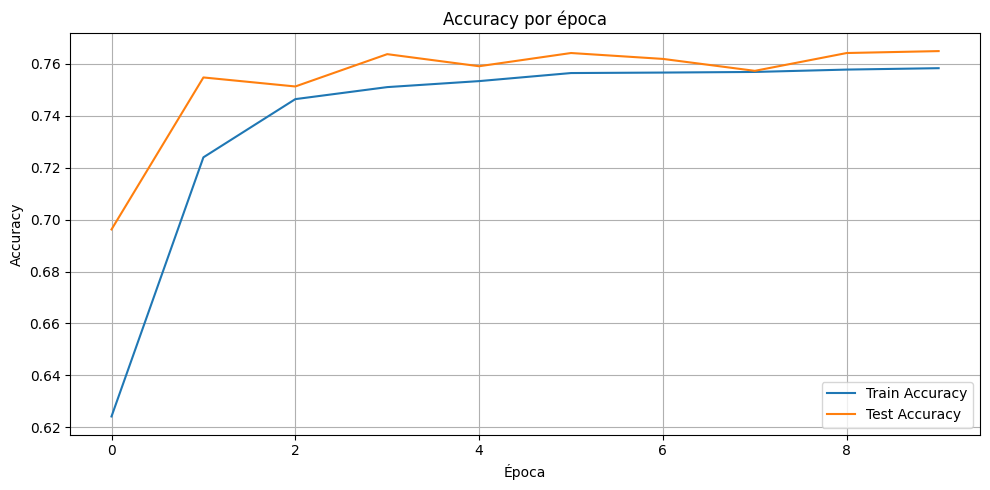

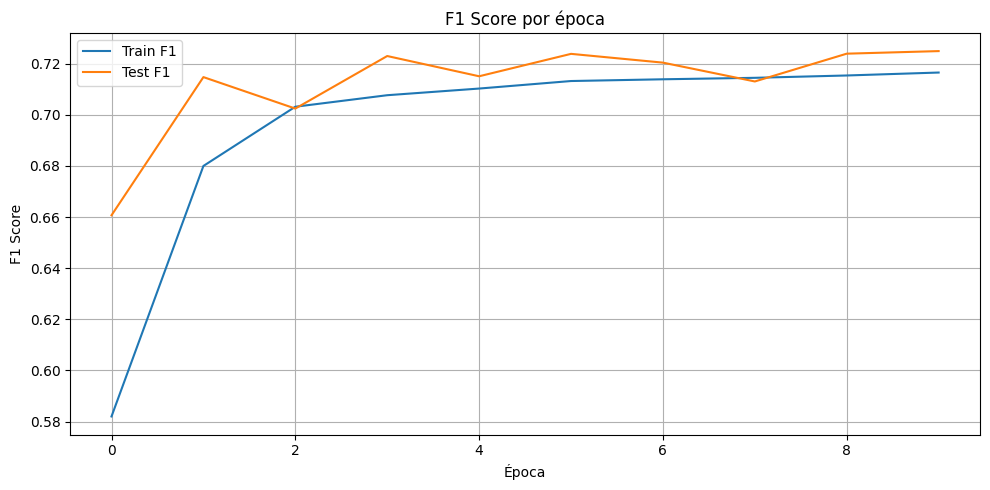

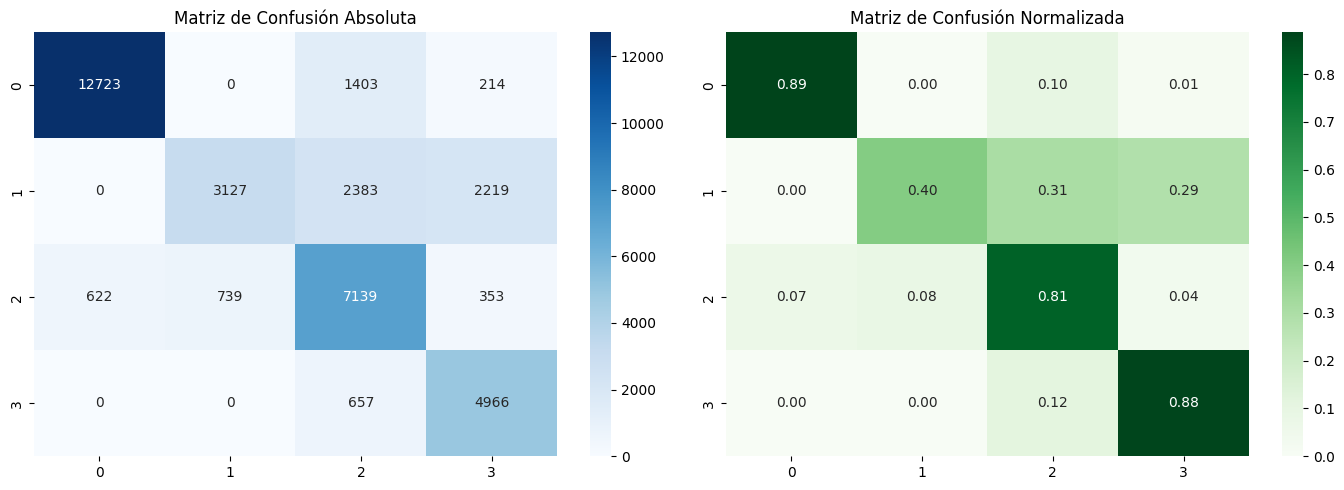

In [32]:
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils import data

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Aplicar preprocesador ya definido y fitteado
preprocessor_without_drop.fit(X_train)
X_train_proc = preprocessor_without_drop.transform(X_train)
X_test_proc = preprocessor_without_drop.transform(X_test)

# A tensor
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

# Dataset y dataloader
train_ds = data.TensorDataset(X_train_tensor, y_train_tensor)
test_ds = data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = data.DataLoader(test_ds, batch_size=128)

class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims = None, dropout_rate=0.1):
        super().__init__()

        layers = []

        # Construcción automática de arquitectura
        if hidden_dims is None:
            # Solo capa directa de input a output
            layers.append(nn.Linear(input_dim, output_dim))
        else:
            if isinstance(hidden_dims, int):
                hidden_dims = [hidden_dims]

            dims = [input_dim] + hidden_dims + [output_dim]

            for i in range(len(dims) - 2):
                layers.append(nn.Linear(dims[i], dims[i + 1]))
                #layers.append(nn.BatchNorm1d(dims[i + 1]))
                layers.append(nn.GELU())
                layers.append(nn.Dropout(dropout_rate))

            # Última capa sin activación ni dropout
            layers.append(nn.Linear(dims[-2], dims[-1]))

        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

def train_model(model, optimizer, loss_module, train_loader, test_loader, scheduler, num_epochs=30):
    train_loss_list, test_loss_list = [], []
    train_acc_list, test_acc_list = [], []
    train_f1_list, test_f1_list = [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        y_true_train, y_pred_train = [], []

        for data_inputs, data_labels in train_loader:
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            optimizer.zero_grad()
            preds = model(data_inputs)
            loss = loss_module(preds, data_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * data_inputs.size(0)
            y_true_train += data_labels.cpu().tolist()
            y_pred_train += preds.argmax(1).cpu().tolist()

        scheduler.step()

        avg_loss = total_loss / len(train_loader.dataset)
        train_loss_list.append(avg_loss)
        train_acc_list.append(accuracy_score(y_true_train, y_pred_train))
        train_f1_list.append(f1_score(y_true_train, y_pred_train, average='macro'))

        # Evaluar en test
        model.eval()
        y_true_test, y_pred_test = [], []
        test_loss = 0.0
        with torch.no_grad():
            for data_inputs, data_labels in test_loader:
                data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
                preds = model(data_inputs)
                loss = loss_module(preds, data_labels)

                test_loss += loss.item() * data_inputs.size(0)
                y_true_test += data_labels.cpu().tolist()
                y_pred_test += preds.argmax(1).cpu().tolist()

        test_loss /= len(test_loader.dataset)
        test_loss_list.append(test_loss)
        test_acc_list.append(accuracy_score(y_true_test, y_pred_test))
        test_f1_list.append(f1_score(y_true_test, y_pred_test, average='macro'))

        print(f"Epoch {epoch+1:02d}: "
              f"Train Acc: {train_acc_list[-1]*100:.2f}% | "
              f"Test Acc: {test_acc_list[-1]*100:.2f}% | "
              f"Train F1: {train_f1_list[-1]*100:.2f}% | "
              f"Test F1: {test_f1_list[-1]*100:.2f}%")

    return (
        train_loss_list, test_loss_list,
        train_acc_list, test_acc_list,
        train_f1_list, test_f1_list,
        y_true_test, y_pred_test
    )


# Configuración
input_dim = X_train_tensor.shape[1] 
output_dim = 4
dropout_rate = 0.1


model = SimpleClassifier(input_dim, output_dim, hidden_dims=[512, 256, 128], dropout_rate= 0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
loss_module = nn.CrossEntropyLoss()

(
    train_loss_list, test_loss_list,
    train_acc_list, test_acc_list,
    train_f1_list, test_f1_list,
    y_true_test, y_pred_test
) = train_model(model, optimizer, loss_module, train_loader, test_loader, scheduler, num_epochs=10)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.title("Evolución de la función de costo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# F1 Score
plt.figure(figsize=(10, 5))
plt.plot(train_f1_list, label="Train F1")
plt.plot(test_f1_list, label="Test F1")
plt.title("F1 Score por época")
plt.xlabel("Época")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_true_test, y_pred_test)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axs[0])
axs[0].set_title("Matriz de Confusión Absoluta")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axs[1])
axs[1].set_title("Matriz de Confusión Normalizada")
plt.tight_layout()
plt.show()


## Parte 2d - Modelo de Deep Learning con embeddings

Se desarrolló un modelo de deep learning en PyTorch que incorpora dos capas de embeddings: una para los `user_id` y otra para los `product_id`. A diferencia del modelo del punto 2c, donde dichas variables fueron descartadas, en este caso se conservaron y transformaron mediante `LabelEncoder` para alimentar las capas `nn.Embedding`.

---

#### **Arquitectura y entrenamiento**

- Embedding de usuarios: dimensión 2
- Embedding de productos: dimensión 2
- Una única capa oculta con 8 neuronas
- Activación: ReLU
- Regularización: Dropout(0.1)
- Optimizador: AdamW
- Scheduler: `StepLR(step_size=3, gamma=0.5)`
- Épocas entrenadas: 12

---
### Comparación con el modelo sin embeddings (2c)

| Modelo            | Accuracy | F1 Score | Observaciones                     |
|-------------------|----------|----------|-----------------------------------|
| Sin embeddings    | 76.30%   | 72.20%   | Buen rendimiento sin IDs          |
| Con embeddings    | 96.52%   | 96.33%   | Mayor capacidad predictiva        |

La diferencia de performance se justifica por la incorporación explícita de la relación usuario-producto, capturada a través de los vectores latentes (embeddings). Estos permitieron al modelo capturar patrones individuales sin necesidad de sobreajustar, gracias a la reducción en la capacidad del modelo (una única capa de 8 neuronas) y la correcta regularización.

---

### Resultado final (época 12)

- **Train Accuracy:** 95.02%  
- **Test Accuracy:** 96.52%  
- **Train F1 Score:** 94.62%  
- **Test F1 Score:** 96.33%

---

**Conclusión:** El modelo con embeddings mejora significativamente la performance respecto al modelo base.

In [54]:
# 1. Cargar el dataset
df = pd.read_csv("dataset_compras.csv")

def limpiar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Elimina columnas innecesarias del DataFrame.

    :param df: DataFrame original.
    :return: DataFrame sin columnas ID y subcategorías.
    """
    columnas_a_eliminar = [
        "Product_Subcategory_1",
        "Product_Subcategory_2"
    ]
    df = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])
    return df

# Ejecución del pipeline de preprocesamiento
df = crear_segmento(df)
df = limpiar_columnas(df)
df = estandarizar_formatos(df)


# Eliminar variable de fuga
df = df.drop(columns=["Purchase"])

Epoch 01: Train Acc: 42.72% | Test Acc: 51.28% | Train F1: 32.40% | Test F1: 41.22%
Epoch 02: Train Acc: 57.74% | Test Acc: 68.88% | Train F1: 53.25% | Test F1: 66.40%
Epoch 03: Train Acc: 72.61% | Test Acc: 80.47% | Train F1: 70.91% | Test F1: 78.75%
Epoch 04: Train Acc: 81.33% | Test Acc: 85.43% | Train F1: 79.91% | Test F1: 84.33%
Epoch 05: Train Acc: 85.96% | Test Acc: 89.41% | Train F1: 84.93% | Test F1: 88.64%
Epoch 06: Train Acc: 89.55% | Test Acc: 92.60% | Train F1: 88.78% | Test F1: 92.08%
Epoch 07: Train Acc: 91.59% | Test Acc: 93.88% | Train F1: 90.96% | Test F1: 93.53%
Epoch 08: Train Acc: 92.66% | Test Acc: 94.75% | Train F1: 92.13% | Test F1: 94.46%
Epoch 09: Train Acc: 93.60% | Test Acc: 95.72% | Train F1: 93.12% | Test F1: 95.48%
Epoch 10: Train Acc: 94.24% | Test Acc: 96.01% | Train F1: 93.78% | Test F1: 95.79%
Epoch 11: Train Acc: 94.64% | Test Acc: 96.32% | Train F1: 94.22% | Test F1: 96.12%
Epoch 12: Train Acc: 95.02% | Test Acc: 96.52% | Train F1: 94.62% | Test F1:

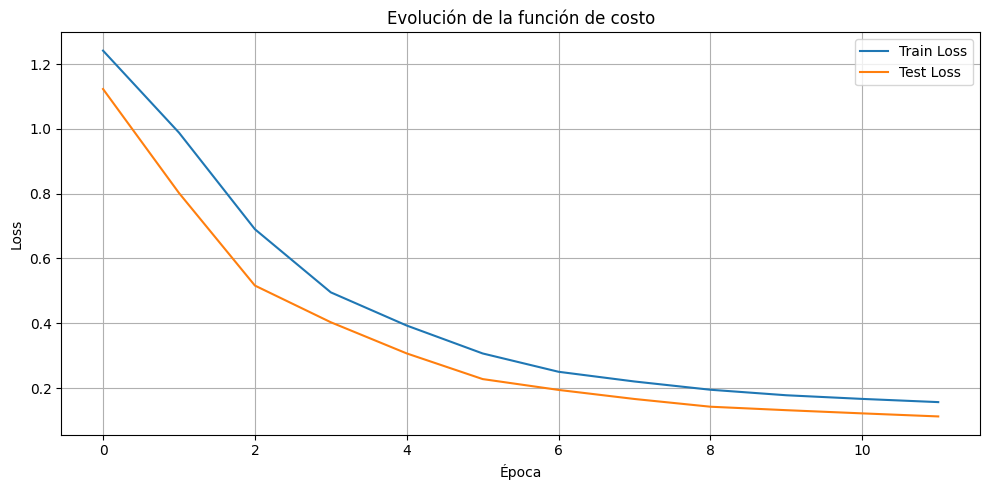

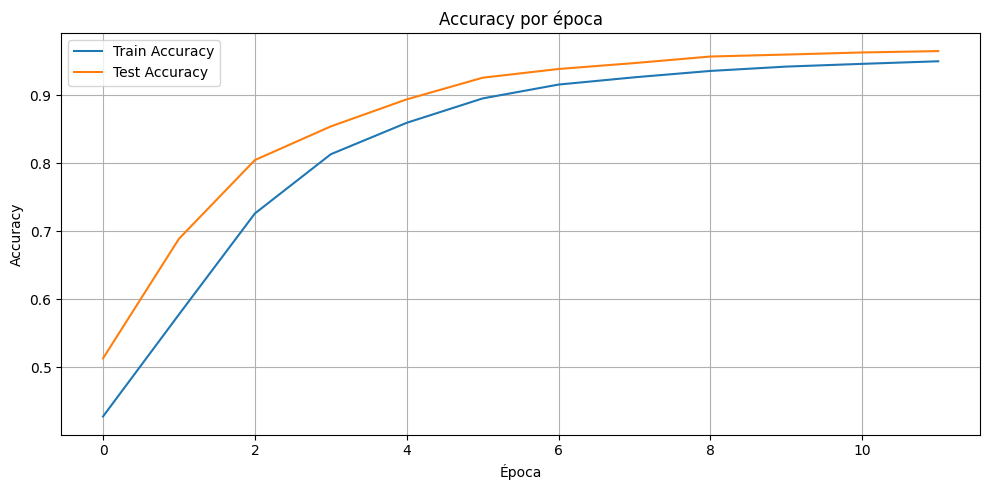

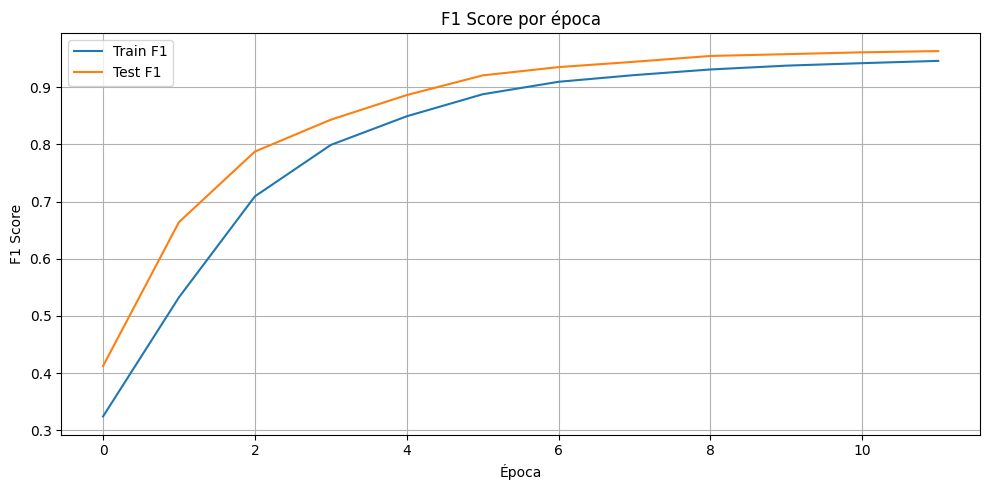

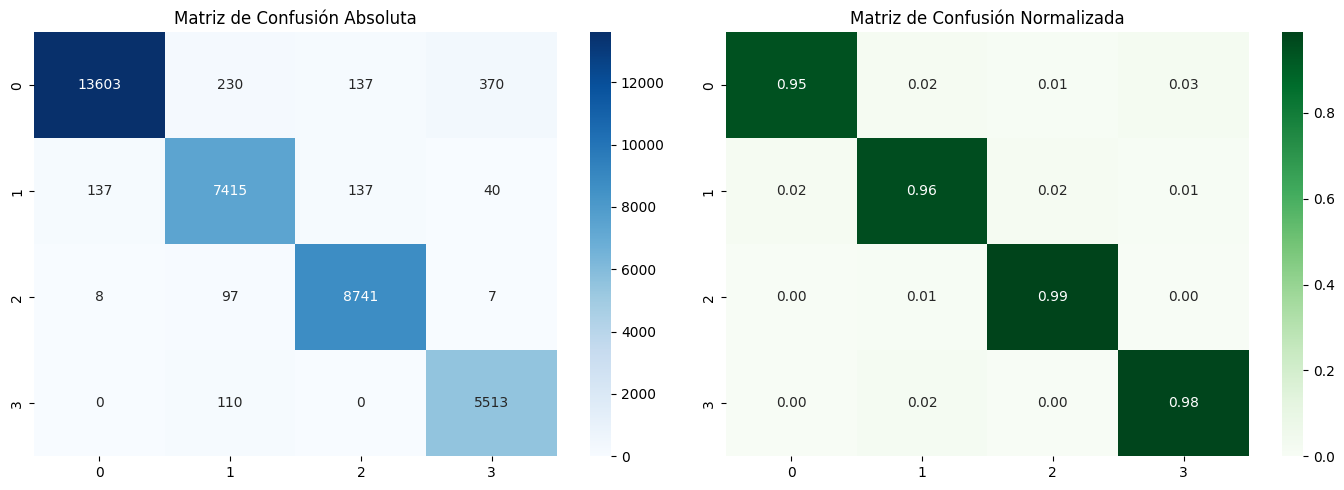

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils import data


# Codificar user/product ID
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()
df["user_id_enc"] = user_encoder.fit_transform(df["User_ID"])
df["product_id_enc"] = product_encoder.fit_transform(df["Product_ID"])

n_users = df["user_id_enc"].nunique()
n_products = df["product_id_enc"].nunique()

# Separar X_full e y (sin preparar ni transformar)
y = df["Segmento"]
X_full = df.drop(columns=["Segmento"])


# Split explícito con IDs incluidos
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Extraer embeddings
user_train = X_train_full["user_id_enc"].values
user_test = X_test_full["user_id_enc"].values
product_train = X_train_full["product_id_enc"].values
product_test = X_test_full["product_id_enc"].values

# Eliminar columnas innecesarias luego del split
X_train = X_train_full.drop(columns=["User_ID", "Product_ID", "user_id_enc", "product_id_enc"])
X_test = X_test_full.drop(columns=["User_ID", "Product_ID", "user_id_enc", "product_id_enc"])


label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Detectar columnas por tipo
cat_cols = X_train.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Definir columna ordinal y su orden
col_ordinal = ["Age"]
orden_edad = [["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]]

# Separar categóricas ordinales de nominales
cat_nominal = [col for col in cat_cols if col not in col_ordinal]

# Preprocesador para modelos que NO requieren drop
preprocessor_without_drop = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("nom", OneHotEncoder(), cat_nominal),
    ("ord", OrdinalEncoder(categories=orden_edad), col_ordinal)
])

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Aplicar preprocesador ya definido y fitteado
preprocessor_without_drop.fit(X_train)
X_train_proc = preprocessor_without_drop.transform(X_train)
X_test_proc = preprocessor_without_drop.transform(X_test)

# A tensor
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)

user_train_tensor = torch.tensor(user_train, dtype=torch.long)
user_test_tensor = torch.tensor(user_test, dtype=torch.long)

product_train_tensor = torch.tensor(product_train, dtype=torch.long)
product_test_tensor = torch.tensor(product_test, dtype=torch.long)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

train_ds = data.TensorDataset(X_train_tensor, user_train_tensor, product_train_tensor, y_train_tensor)
test_ds = data.TensorDataset(X_test_tensor, user_test_tensor, product_test_tensor, y_test_tensor)


train_loader = data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = data.DataLoader(test_ds, batch_size=128)

class EmbeddingClassifier(nn.Module):
    def __init__(self, n_users, n_products, input_dim, output_dim,
                 emb_dim_user=32, emb_dim_product=32, hidden_dims=[128, 64, 32]):
        super().__init__()

        self.user_emb = nn.Embedding(n_users, emb_dim_user)
        self.product_emb = nn.Embedding(n_products, emb_dim_product)

        mlp_input_dim = input_dim + emb_dim_user + emb_dim_product
        dims = [mlp_input_dim] + hidden_dims + [output_dim]

        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
        layers.append(nn.Linear(dims[-2], dims[-1]))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, user_idx, product_idx):
        u = self.user_emb(user_idx)
        p = self.product_emb(product_idx)
        x = torch.cat([x_num, u, p], dim=1)
        return self.mlp(x)


def train_model(model, optimizer, loss_fn, train_loader, test_loader, scheduler, num_epochs=5):
    train_loss, test_loss = [], []
    train_acc, test_acc = [], []
    train_f1, test_f1 = [], []

    for epoch in range(num_epochs):
        model.train()
        y_true_train, y_pred_train = [], []
        epoch_loss = 0.0

        for x_num, user, prod, label in train_loader:
            x_num, user, prod, label = x_num.to(device), user.to(device), prod.to(device), label.to(device)
            optimizer.zero_grad()
            preds = model(x_num, user, prod)
            loss = loss_fn(preds, label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_num.size(0)
            y_true_train += label.cpu().tolist()
            y_pred_train += preds.argmax(1).cpu().tolist()

        scheduler.step()

        train_loss.append(epoch_loss / len(train_loader.dataset))
        train_acc.append(accuracy_score(y_true_train, y_pred_train))
        train_f1.append(f1_score(y_true_train, y_pred_train, average='macro'))

        # Test
        model.eval()
        y_true_test, y_pred_test = [], []
        total_loss = 0.0
        with torch.no_grad():
            for x_num, user, prod, label in test_loader:
                x_num, user, prod, label = x_num.to(device), user.to(device), prod.to(device), label.to(device)
                preds = model(x_num, user, prod)
                total_loss += loss_fn(preds, label).item() * x_num.size(0)
                y_true_test += label.cpu().tolist()
                y_pred_test += preds.argmax(1).cpu().tolist()

        test_loss.append(total_loss / len(test_loader.dataset))
        test_acc.append(accuracy_score(y_true_test, y_pred_test))
        test_f1.append(f1_score(y_true_test, y_pred_test, average='macro'))

        print(f"Epoch {epoch+1:02d}: "
              f"Train Acc: {train_acc[-1]*100:.2f}% | "
              f"Test Acc: {test_acc[-1]*100:.2f}% | "
              f"Train F1: {train_f1[-1]*100:.2f}% | "
              f"Test F1: {test_f1[-1]*100:.2f}%")

    return train_loss, test_loss, train_acc, test_acc, train_f1, test_f1, y_true_test, y_pred_test



input_dim = X_train_tensor.shape[1]
output_dim = len(label_encoder.classes_)

model = EmbeddingClassifier(
    n_users=n_users,
    n_products=n_products,
    input_dim=input_dim,
    output_dim=output_dim,
    emb_dim_user=2,
    emb_dim_product=2,
    hidden_dims=[8]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
loss_fn = nn.CrossEntropyLoss()

train_loss, test_loss, train_acc, test_acc, train_f1, test_f1, y_true_test, y_pred_test = train_model(
    model, optimizer, loss_fn, train_loader, test_loader, scheduler, num_epochs=12
)



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

train_loss_list = train_loss
test_loss_list = test_loss
train_acc_list = train_acc
test_acc_list = test_acc
train_f1_list = train_f1
test_f1_list = test_f1


# Pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.title("Evolución de la función de costo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# F1 Score
plt.figure(figsize=(10, 5))
plt.plot(train_f1_list, label="Train F1")
plt.plot(test_f1_list, label="Test F1")
plt.title("F1 Score por época")
plt.xlabel("Época")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_true_test, y_pred_test)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axs[0])
axs[0].set_title("Matriz de Confusión Absoluta")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axs[1])
axs[1].set_title("Matriz de Confusión Normalizada")
plt.tight_layout()
plt.show()
